## GSEA with Cell Type Signature Gene Sets (Merged by Cell Type)

In [1]:
import pandas as pd
import gseapy as gp
from pathlib import Path
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import pdist

In [2]:
merged_celltype_gmt_path = "gsea_gene_set/C8_merged_by_cell_type.gmt"
spectra_dir = Path("all_datasets_consensus/anal_pc5_c21_S1.filtered_consensus_outputs")
out_dir = Path("gsea_results_celltype_merged")
out_dir.mkdir(parents=True, exist_ok=True)

# === GSEA PARAMETERS ===
min_size = 15
max_size = 500
permutation_num = 1000
seed = 42

# === MERGING OPTIONS ===
min_sources_required = 1  # Minimum number of sources to include a merged cell type
save_merged_gmt = True    # Save the merged GMT file for reuse

### Find Spectra Files and Run GSEA

In [3]:
# Find spectra score files
pattern = re.compile(r"\.gene_spectra_score\.k_(\d+)\.dt_0_01\.txt$")

spectra_files = []
for fp in spectra_dir.glob("*.gene_spectra_score.k_*.dt_0_01.txt"):
    m = pattern.search(fp.name)
    if m:
        K = int(m.group(1))
        spectra_files.append((K, fp))

if not spectra_files:
    raise FileNotFoundError(f"No spectra files found in {spectra_dir}")

spectra_files.sort(key=lambda x: x[0])

print(f"Found {len(spectra_files)} spectra files")
print(f"K values: {[k for k, _ in spectra_files]}")

Found 17 spectra files
K values: [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]


In [4]:
# Run GSEA for all K values and GEPs
all_rows = []

for K, fp in spectra_files:
    print(f"Processing K={K}: {fp.name}")
    spectra = pd.read_csv(fp, sep="\t", index_col=0)  # rows=GEPs, cols=genes
    spectra.columns = spectra.columns.astype(str)
    
    for gep in spectra.index:
        # Create preranked list: genes sorted by score
        rnk = spectra.loc[gep].sort_values(ascending=False)
        
        # Run GSEA prerank with merged cell type gene sets
        prerank_res = gp.prerank(
            rnk=rnk,
            gene_sets=merged_celltype_gmt_path,  # Using the merged dictionary
            min_size=min_size,
            max_size=max_size,
            permutation_num=permutation_num,
            seed=seed,
            outdir=None,
            verbose=False
        )
        
        res = prerank_res.res2d.copy()
        res["K"] = K
        res["GEP"] = str(gep)
        res["spectra_file"] = fp.name
        
        all_rows.append(res)

print("\nGSEA complete! ✅")

2026-01-22 16:41:25,661 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


Processing K=5: anal_pc5_c21_S1.filtered.gene_spectra_score.k_5.dt_0_01.txt


2026-01-22 16:41:28,214 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-22 16:41:30,571 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-22 16:41:32,909 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-22 16:41:35,242 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-22 16:41:37,663 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


Processing K=6: anal_pc5_c21_S1.filtered.gene_spectra_score.k_6.dt_0_01.txt


2026-01-22 16:41:40,087 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-22 16:41:42,561 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-22 16:41:44,972 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-22 16:41:47,356 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-22 16:41:50,080 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-22 16:41:52,578 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be

...

Processing K=20: anal_pc5_c21_S1.filtered.gene_spectra_score.k_20.dt_0_01.txt


2026-01-22 16:48:34,567 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-22 16:48:36,875 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-22 16:48:39,178 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-22 16:48:41,494 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-22 16:48:43,810 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-22 16:48:46,114 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be

Processing K=21: anal_pc5_c21_S1.filtered.gene_spectra_score.k_21.dt_0_01.txt


2026-01-22 16:49:20,935 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-22 16:49:23,255 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-22 16:49:25,563 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-22 16:49:27,873 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-22 16:49:30,187 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-22 16:49:32,509 [WARNING] Duplicated values found in preranked stats: 0.20% of genes
The order of those genes will be


GSEA complete! ✅


In [5]:
# Combine all results
summary = pd.concat(all_rows, ignore_index=True)

# Standardize column names
col_rename = {
    'Term': 'pathway',
    'NOM p-val': 'pval',
    'FDR q-val': 'fdr',
}
summary.rename(columns={k: v for k, v in col_rename.items() if k in summary.columns}, inplace=True)

# Reorder columns
first_cols = ['K', 'GEP', 'pathway', 'NES', 'pval', 'fdr']
other_cols = [c for c in summary.columns if c not in first_cols]
summary = summary[[c for c in first_cols if c in summary.columns] + other_cols]

print(f"Total results: {len(summary)} rows")
print(f"Columns: {list(summary.columns)}")
summary.head(10)

Total results: 135694 rows
Columns: ['K', 'GEP', 'pathway', 'NES', 'pval', 'fdr', 'Name', 'ES', 'FWER p-val', 'Tag %', 'Gene %', 'Lead_genes', 'spectra_file']


,K,GEP,pathway,NES,pval,fdr,Name,ES,FWER p-val,Tag %,Gene %,Lead_genes,spectra_file
0,5,1,LYMPHOID,3.518102,0.0,0.0,prerank,0.847394,0.0,188/238,14.26%,ARHGEF1;CORO1A;TMC8;SEPTIN1;TRAF3IP3;TBC1D10C;...,anal_pc5_c21_S1.filtered.gene_spectra_score.k_...
1,5,1,INTESTINE_ADULT_CI_MESENCHYMAL,3.34249,0.0,0.0,prerank,0.803995,0.0,190/261,15.08%,ACAP1;CORO1A;ITGAL;TMC8;ARHGAP15;SEPTIN1;IKZF1...,anal_pc5_c21_S1.filtered.gene_spectra_score.k_...
2,5,1,B_T,3.323489,0.0,0.0,prerank,0.863049,0.0,106/123,11.84%,ARHGEF1;EVL;ACAP1;CORO1A;ITGAL;TMC8;ARHGAP15;S...,anal_pc5_c21_S1.filtered.gene_spectra_score.k_...
3,5,1,CTX_BRAIN_NAIVE_LIKE_T,3.276513,0.0,0.0,prerank,0.854714,0.0,93/110,10.88%,ARHGEF1;ACAP1;CORO1A;ARHGAP15;SEPTIN1;TRAF3IP3...,anal_pc5_c21_S1.filtered.gene_spectra_score.k_...
4,5,1,KIDNEY_LYMPHOID,3.274699,0.0,0.0,prerank,0.836633,0.0,119/143,14.14%,ACAP1;SEPTIN1;CD2;LTB;IL2RG;CARMIL2;ZAP70;TRBC...,anal_pc5_c21_S1.filtered.gene_spectra_score.k_...
5,5,1,MARROW_NAIVE_T,3.231388,0.0,0.0,prerank,0.808169,0.0,132/170,15.22%,ARHGEF1;EVL;ACAP1;TMC8;ARHGAP15;SEPTIN1;TRAF3I...,anal_pc5_c21_S1.filtered.gene_spectra_score.k_...
6,5,1,ADRENAL_LYMPHOID,3.230583,0.0,0.0,prerank,0.832167,0.0,111/133,14.14%,ACAP1;SEPTIN1;TRAF3IP3;TBC1D10C;CD2;LTB;CD96;I...,anal_pc5_c21_S1.filtered.gene_spectra_score.k_...
7,5,1,INTESTINE_LYMPHOID,3.211105,0.0,0.0,prerank,0.830837,0.0,100/129,13.66%,ACAP1;SEPTIN1;TBC1D10C;CD2;LTB;CD96;IL2RG;ZAP7...,anal_pc5_c21_S1.filtered.gene_spectra_score.k_...
8,5,1,NK_NKT,3.147081,0.0,0.0,prerank,0.748801,0.0,198/308,14.92%,EVL;AKNA;CORO1A;ITGAL;TMC8;IKZF1;WIPF1;TBC1D10...,anal_pc5_c21_S1.filtered.gene_spectra_score.k_...
9,5,1,CTX_BIG_GROUPS_BRAIN_IMMUNE,3.141356,0.0,0.0,prerank,0.842418,0.0,76/97,10.20%,ARHGEF1;AKNA;ACAP1;CORO1A;ITGAL;TMC8;ARHGAP15;...,anal_pc5_c21_S1.filtered.gene_spectra_score.k_...


In [6]:
# Save results
output_csv = out_dir / "celltype_gsea_all_K_all_GEPs_tidy.csv"
summary.to_csv(output_csv, index=False)
print(f"Saved results to: {output_csv}")

# Also save per-K files
for K in summary['K'].unique():
    k_data = summary[summary['K'] == K]
    k_path = out_dir / f"K{K}_celltype_gsea.csv"
    k_data.to_csv(k_path, index=False)
print(f"Saved per-K files to: {out_dir}")

Saved results to: gsea_results_celltype_merged/celltype_gsea_all_K_all_GEPs_tidy.csv
Saved per-K files to: gsea_results_celltype_merged


### Part 3: Visualize Results

In [7]:
# Summary statistics
print("RESULTS SUMMARY")
print("="*50)

for K in sorted(summary['K'].unique()):
    k_data = summary[summary['K'] == K]
    n_sig_005 = (k_data['fdr'] < 0.05).sum()
    n_sig_025 = (k_data['fdr'] < 0.25).sum()
    print(f"K={K}: {len(k_data)} total, {n_sig_005} sig (FDR<0.05), {n_sig_025} sig (FDR<0.25)")

RESULTS SUMMARY
K=5: 3070 total, 1213 sig (FDR<0.05), 1695 sig (FDR<0.25)
K=6: 3684 total, 1286 sig (FDR<0.05), 1850 sig (FDR<0.25)
K=7: 4298 total, 1423 sig (FDR<0.05), 2048 sig (FDR<0.25)
K=8: 4912 total, 1532 sig (FDR<0.05), 2225 sig (FDR<0.25)
K=9: 5526 total, 1709 sig (FDR<0.05), 2526 sig (FDR<0.25)
K=10: 6140 total, 1858 sig (FDR<0.05), 2849 sig (FDR<0.25)
K=11: 6754 total, 2006 sig (FDR<0.05), 3098 sig (FDR<0.25)
K=12: 7368 total, 2058 sig (FDR<0.05), 3207 sig (FDR<0.25)
K=13: 7982 total, 2106 sig (FDR<0.05), 3498 sig (FDR<0.25)
K=14: 8596 total, 2172 sig (FDR<0.05), 3610 sig (FDR<0.25)
K=15: 9210 total, 2262 sig (FDR<0.05), 3792 sig (FDR<0.25)
K=16: 9824 total, 2344 sig (FDR<0.05), 3814 sig (FDR<0.25)
K=17: 10438 total, 2735 sig (FDR<0.05), 4370 sig (FDR<0.25)
K=18: 11052 total, 2563 sig (FDR<0.05), 4354 sig (FDR<0.25)
K=19: 11666 total, 3142 sig (FDR<0.05), 4849 sig (FDR<0.25)
K=20: 12280 total, 3021 sig (FDR<0.05), 4883 sig (FDR<0.25)
K=21: 12894 total, 2772 sig (FDR<0.05), 4

In [8]:
def plot_gsea_heatmap(data: pd.DataFrame, K: int, fdr_thresh: float = 0.25, 
                      figsize: tuple = (16, 10), top_n: int = None):
    """
    Create a clustered heatmap of GSEA results.
    """
    k_data = data[data['K'] == K].copy()
    k_data['GEP_label'] = 'GEP' + k_data['GEP'].astype(str)
    
    # Pivot for heatmap
    heatmap_data = k_data.pivot_table(
        index='GEP_label',
        columns='pathway',
        values='NES',
        aggfunc='first'
    )
    
    # Filter to significant pathways
    sig_pathways = k_data[k_data['fdr'] < fdr_thresh]['pathway'].unique()
    heatmap_data = heatmap_data[heatmap_data.columns.intersection(sig_pathways)]
    
    if len(heatmap_data.columns) == 0:
        print(f"No significant pathways at FDR < {fdr_thresh} for K={K}")
        return None
    
    # Optionally limit to top N pathways
    if top_n and len(heatmap_data.columns) > top_n:
        max_nes = heatmap_data.abs().max()
        top_pathways = max_nes.nlargest(top_n).index
        heatmap_data = heatmap_data[top_pathways]
    
    # === FIX: Convert to float and handle NaNs ===
    heatmap_data = heatmap_data.astype(float)
    heatmap_data = heatmap_data.fillna(0)
    
    print(f"Plotting {len(heatmap_data.columns)} pathways for K={K}")
    
    # Create clustered heatmap
    g = sns.clustermap(
        heatmap_data,
        cmap='RdBu_r',
        center=0,
        figsize=figsize,
        xticklabels=True,
        yticklabels=True,
        dendrogram_ratio=(0.15, 0.08),
        cbar_pos=(0.02, 0.8, 0.03, 0.15),
        cbar_kws={'label': 'NES'},
        method='ward',
        metric='euclidean',
        row_cluster=True,
        col_cluster=True,
    )
    
    g.ax_heatmap.set_xlabel('Cell Type', fontsize=11)
    g.ax_heatmap.set_ylabel('Gene Expression Program', fontsize=11)
    g.ax_heatmap.tick_params(axis='x', labelsize=7, rotation=90)
    g.ax_heatmap.tick_params(axis='y', labelsize=9)
    
    g.fig.suptitle(f'Cell Type Enrichment × GEPs (K={K}, FDR<{fdr_thresh})', 
                   fontsize=13, y=1.02)
    
    return g

Plotting 571 pathways for K=5


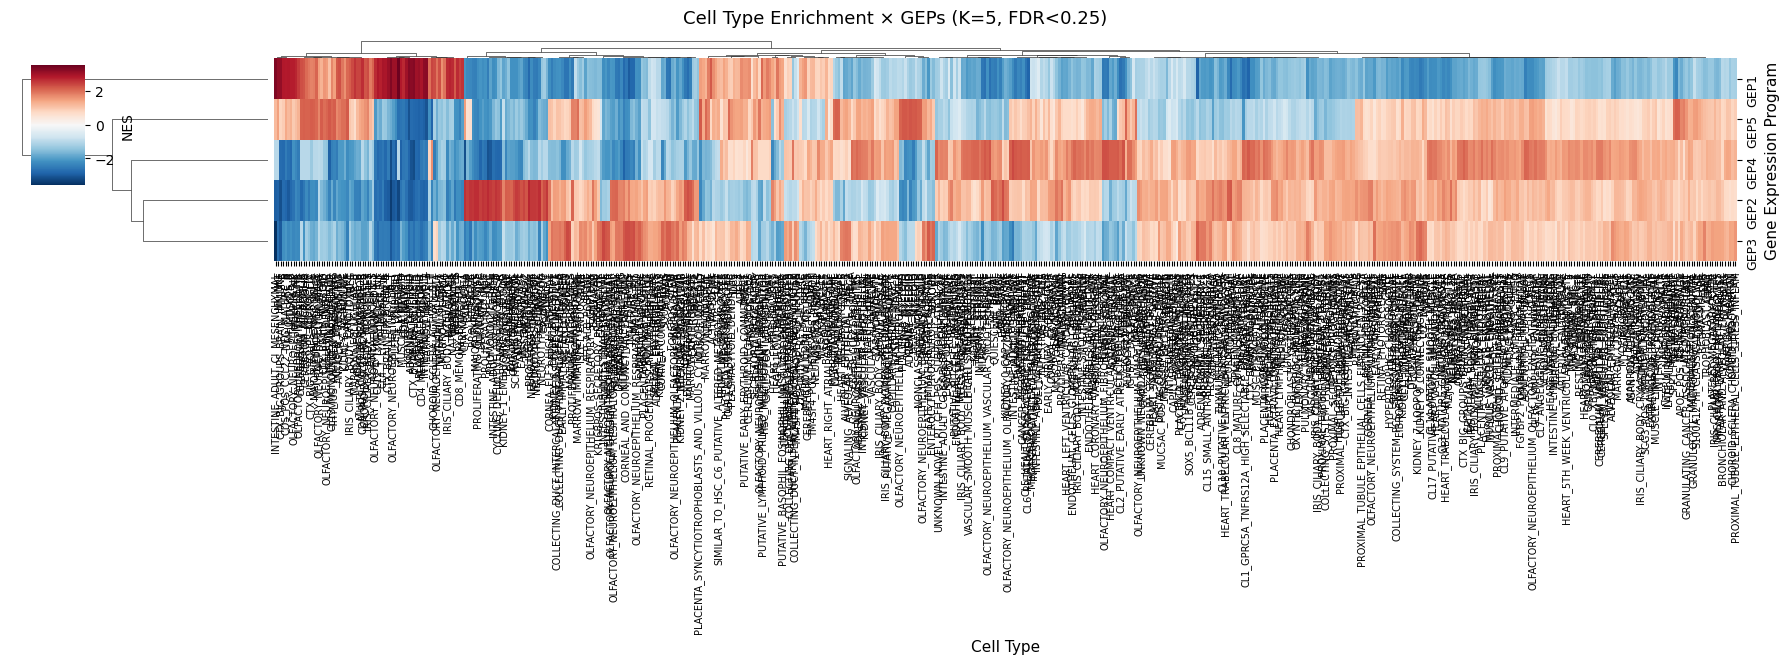

In [9]:
# Plot for K=5 (adjust as needed)
g = plot_gsea_heatmap(summary, K=5, fdr_thresh=0.25, figsize=(18, 8))
if g:
    plt.savefig(out_dir / "K5_celltype_heatmap.png", dpi=150, bbox_inches='tight')
    plt.show()

Plotting 575 pathways for K=6


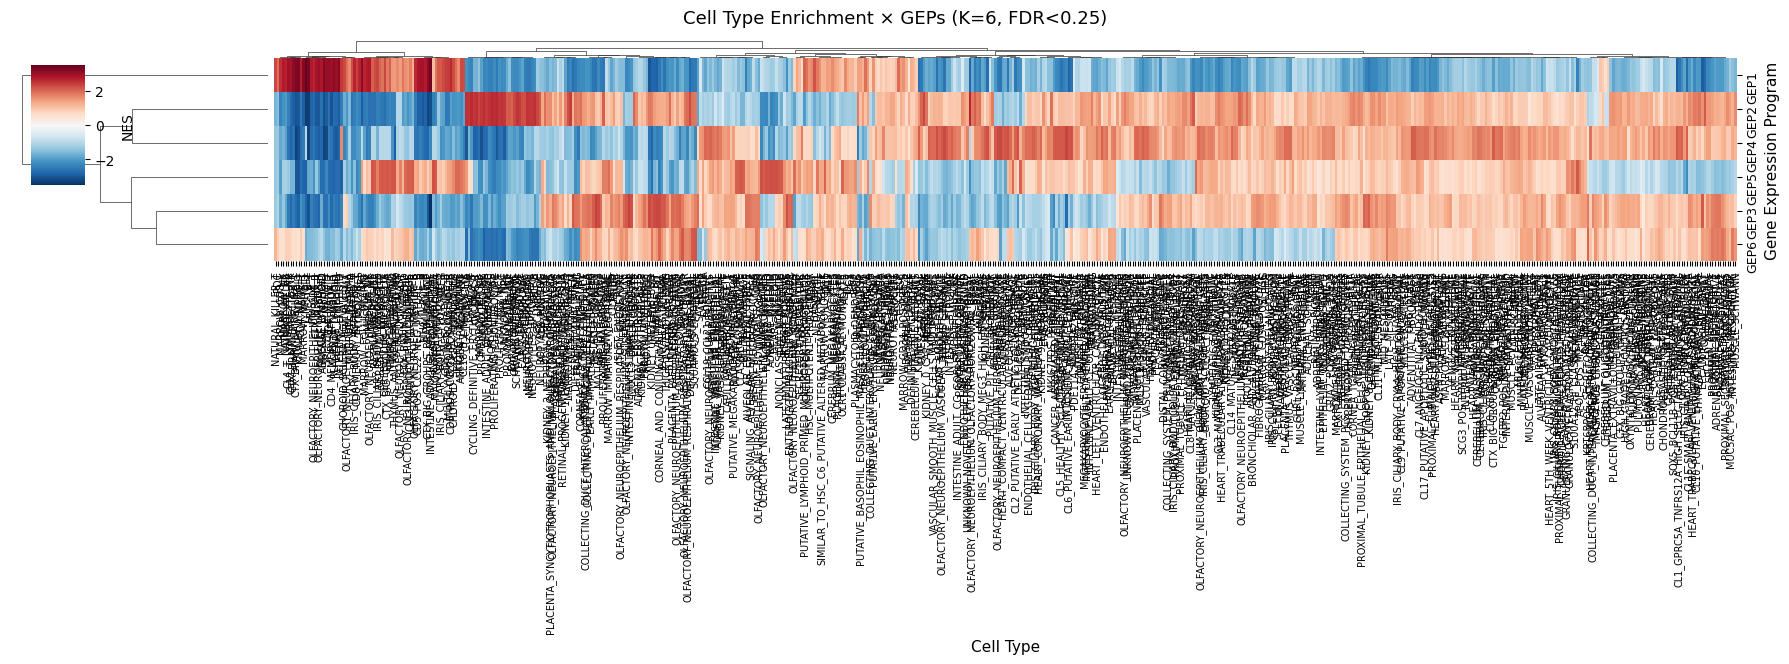

Plotting 577 pathways for K=7


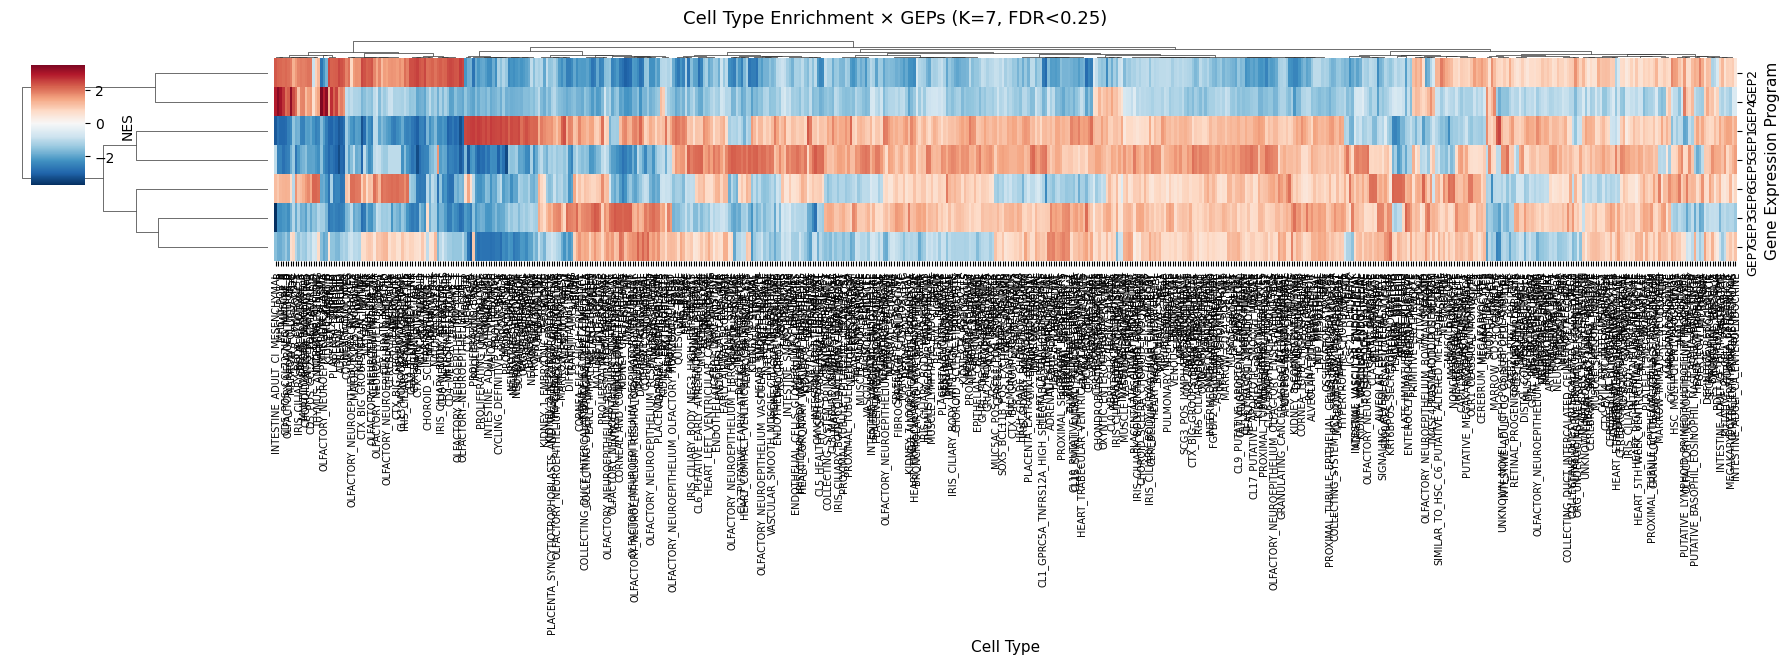

Plotting 579 pathways for K=8


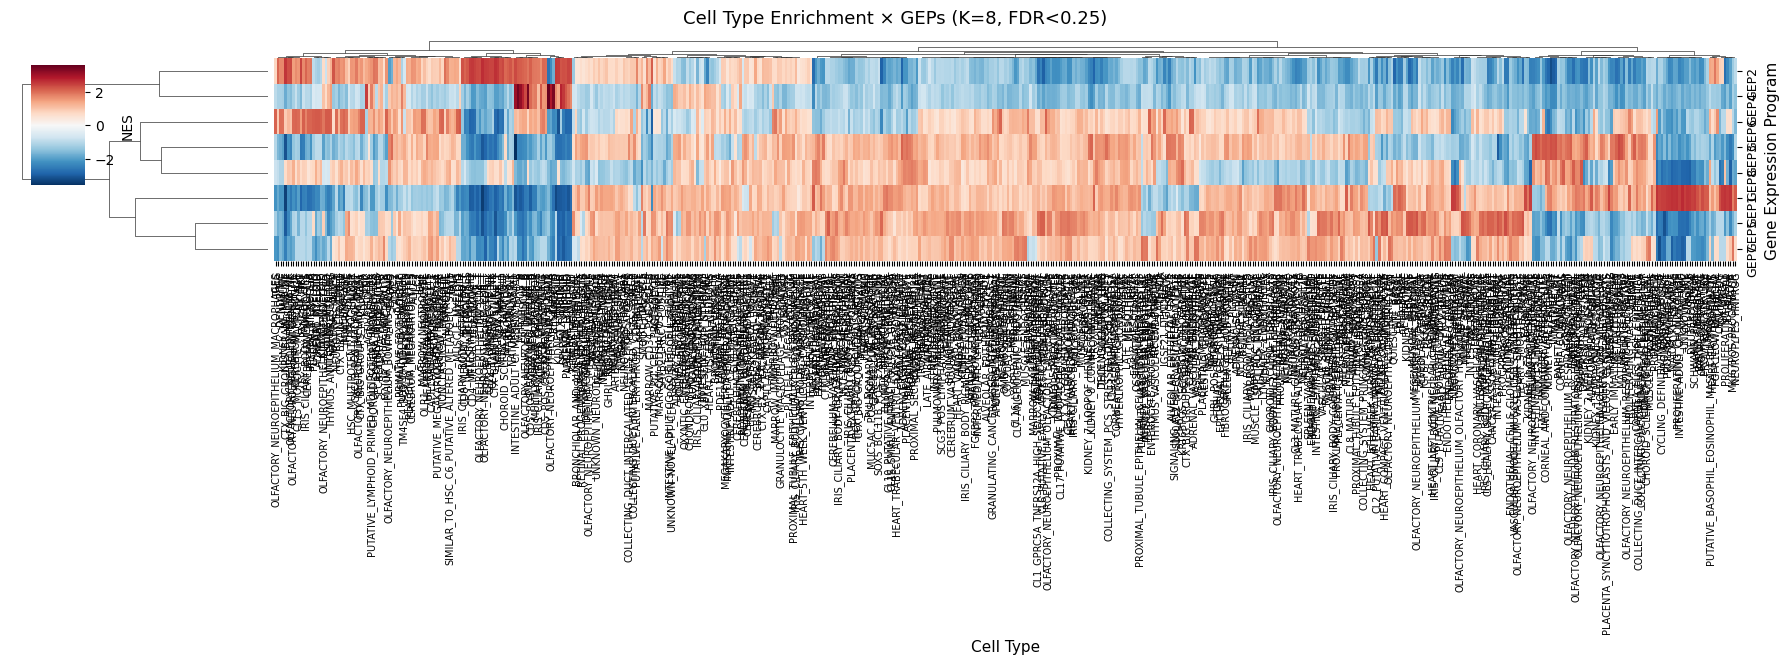

In [10]:
# Plot for multiple K values
for K in [6, 7, 8]:  # Adjust as needed
    if K in summary['K'].values:
        g = plot_gsea_heatmap(summary, K=K, fdr_thresh=0.25, figsize=(18, 8))
        if g:
            plt.savefig(out_dir / f"K{K}_celltype_heatmap.png", dpi=150, bbox_inches='tight')
            plt.show()

In [11]:
# Show top enrichments for a specific K
K_to_show = 5  # Adjust as needed

k_data = summary[summary['K'] == K_to_show].copy()
k_sig = k_data[k_data['fdr'] < 0.25].sort_values('NES', ascending=False)

print(f"\nTop positive enrichments for K={K_to_show} (FDR < 0.25):")
print(k_sig[['GEP', 'pathway', 'NES', 'fdr']].head(20).to_string(index=False))

print(f"\nTop negative enrichments for K={K_to_show} (FDR < 0.25):")
print(k_sig[['GEP', 'pathway', 'NES', 'fdr']].tail(20).to_string(index=False))


Top positive enrichments for K=5 (FDR < 0.25):
GEP                         pathway       NES  fdr
  1                        LYMPHOID  3.518102  0.0
  1  INTESTINE_ADULT_CI_MESENCHYMAL   3.34249  0.0
  1                             B_T  3.323489  0.0
  1          CTX_BRAIN_NAIVE_LIKE_T  3.276513  0.0
  1                 KIDNEY_LYMPHOID  3.274699  0.0
  1                  MARROW_NAIVE_T  3.231388  0.0
  1                ADRENAL_LYMPHOID  3.230583  0.0
  1              INTESTINE_LYMPHOID  3.211105  0.0
  1                          NK_NKT  3.147081  0.0
  1     CTX_BIG_GROUPS_BRAIN_IMMUNE  3.141356  0.0
  1            CTX_BRAIN_EFFECTOR_T  3.101088  0.0
  1               PLACENTA_LYMPHOID  3.085199  0.0
  1 OLFACTORY_NEUROEPITHELIUM_CD8_T  3.072185  0.0
  1                 SPLEEN_LYMPHOID  3.059684  0.0
  1                  HEART_LYMPHOID  3.034889  0.0
  1                     CD8_NAIVE_T  3.026223  0.0
  1             CL4_T_LYMPHOCYTE_NK  2.959796  0.0
  1           CD4_MEMORY_EFFECTOR_